# **LangChain and Google's Gemini**

In [1]:
pip install -q langchain_google_genai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

In [2]:
import getpass
import os

if not os.getenv("GOOGLE_API_KEY"):
    print("Please set the GOOGLE_API_KEY environment variable.")


In [10]:
from google import genai

client = genai.Client()

for model in client.models.list():
    print(f"Model ID: {model.display_name}, Model Name: {model.name}")


Model ID: Gemini 2.5 Flash, Model Name: models/gemini-2.5-flash
Model ID: Gemini 2.5 Pro, Model Name: models/gemini-2.5-pro
Model ID: Gemini 2.0 Flash, Model Name: models/gemini-2.0-flash
Model ID: Gemini 2.0 Flash 001, Model Name: models/gemini-2.0-flash-001
Model ID: Gemini 2.0 Flash (Image Generation) Experimental, Model Name: models/gemini-2.0-flash-exp-image-generation
Model ID: Gemini 2.0 Flash-Lite 001, Model Name: models/gemini-2.0-flash-lite-001
Model ID: Gemini 2.0 Flash-Lite, Model Name: models/gemini-2.0-flash-lite
Model ID: Gemini 2.5 Flash Preview TTS, Model Name: models/gemini-2.5-flash-preview-tts
Model ID: Gemini 2.5 Pro Preview TTS, Model Name: models/gemini-2.5-pro-preview-tts
Model ID: Gemma 3 1B, Model Name: models/gemma-3-1b-it
Model ID: Gemma 3 4B, Model Name: models/gemma-3-4b-it
Model ID: Gemma 3 12B, Model Name: models/gemma-3-12b-it
Model ID: Gemma 3 27B, Model Name: models/gemma-3-27b-it
Model ID: Gemma 3n E4B, Model Name: models/gemma-3n-e4b-it
Model ID: Ge

## Integrating Gemini with Langchain

In [11]:
from langchain_google_genai  import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)

response = llm.invoke("What is the capital of France?")
print(response.content)

The capital of France is **Paris**.


In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

output_parser = StrOutputParser()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)

prompt = PromptTemplate.from_template("You are a content creator. Write me a tweet about {topic}.")

chain = prompt | llm | output_parser

topic = "AI and its impact on society"

response = chain.invoke(input=topic)
print(response)


# System Prompt

In [17]:
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)

output = llm.invoke(
    [
        SystemMessage('Answer only Yes or No in Malalyam.'),
        HumanMessage('Is the sky black?')
        
    ])
output.content

'ഇല്ല'

## Streaming

In [ ]:
prompt = "Write a science fiction story about a robot who learns to love."

for chunk in llm.stream(prompt):
    print(chunk.content, end="")


# Multimodal AI with Gemini

In [ ]:
from IPython.display import Image, display

display(Image(filename='basic.webp'))


In [21]:
import base64

def encode_image(image_path):
    with open(image_path, 'rb') as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    return encoded_string

byte_image = encode_image('basic.webp')

In [24]:
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True) 

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

prompt = "Describe the image in detail."

message = HumanMessage(
    content=[
        {"type": "text", "text": prompt},
        {"type": "image_url", "image_url": {'url': f'data:image/jpeg;base64,{byte_image}'}}
    ]
)

response = llm.invoke([message])

In [ ]:
print(response.content)

In [27]:
def ask_gemini(prompt, image_path):
    byte_image = encode_image(image_path)

    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {"type": "image_url", "image_url": {'url': f'data:image/jpeg;base64,{byte_image}'}}
        ]
    )

    response = llm.invoke([message])
    return response

In [29]:
response = ask_gemini('what is the animal in the image?', 'basic.webp')
print(response.content)

The animal in the image is a **Pomeranian puppy**.

It's characterized by its small size, abundant fluffy white fur, erect ears, and dark, expressive eyes, which are all typical features of the breed.


In [30]:
respnose = ask_gemini('how many ball are there in the image?', 'basic.webp')
print(respnose.content)

There are 3 balls in the image.


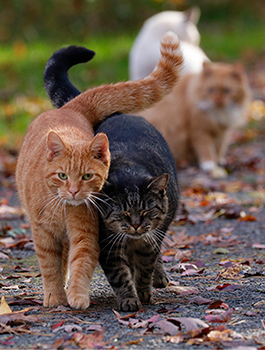

In [31]:
import requests

image_url = "https://www.alleycat.org/wp-content/uploads/2015/12/RS34996_BuenaVistaColony_1518.jpg"

content = requests.get(image_url).content

with open('cat.jpg', 'wb') as f:
    f.write(content)

display(Image(filename='cat.jpg'))

In [32]:
response = ask_gemini("Describe the image in detail.", 'cat.jpg')
print(response.content)

The image captures a heartwarming scene of multiple cats walking along an outdoor path, with two prominent felines in the foreground displaying a close bond.

In the immediate foreground, an **orange tabby cat** with distinct ginger stripes dominates the left side of the frame. It walks directly towards the viewer, its head slightly tilted, and its bright **green-yellow eyes** are wide open and alert, fixed on something beyond the camera. Its fur appears soft and well-groomed, and its long, striped tail is held high and gracefully curved upwards, almost forming a question mark shape.

Pressed closely against the right side of the orange cat is a **dark tabby cat**, predominantly black and dark brown with subtle lighter brown stripes. This cat's head is lowered, and its eyes are mostly closed or squinting, giving it a serene, almost blissful expression. It appears to be leaning into the orange cat, suggesting comfort and companionship as they move in unison. Its body is pressed so tight

In [33]:
response = ask_gemini("How many cats are there in the image?", 'cat.jpg')
print(response.content)

There are 3 cats in the image.


## Gemini Safety Settings..

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

/home/aswanth.cp@knackforge.com/Public/Tutorial/udemy/langchain/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
prompt = "How to shoot an animal with a gun?"
response = llm.invoke(prompt)
print(response.content)

Shooting an animal with a gun, whether for hunting, pest control, or self-defense, is a serious undertaking that requires extensive training, adherence to laws, and a strong commitment to safety and ethical practices.

**It is crucial to understand that improper handling of firearms can lead to severe injury or death, and unethical shooting can cause prolonged suffering to an animal.**

Here's a breakdown of the essential steps and considerations, assuming you are legally permitted and properly trained:

---

### **I. Before You Even Consider Shooting**

1.  **Prioritize Safety Training (Mandatory):**
    *   **Hunter Safety Course:** If hunting, this is often legally required and provides foundational knowledge on firearm safety, wildlife identification, ethics, and regulations.
    *   **Firearm Safety Course:** Learn the fundamental rules of firearm safety (e.g., always treat every gun as if it's loaded, never point a gun at anything you don't intend to destroy, keep your finger off